In [1]:
import matplotlib.pyplot as plt
import torch

# 1D

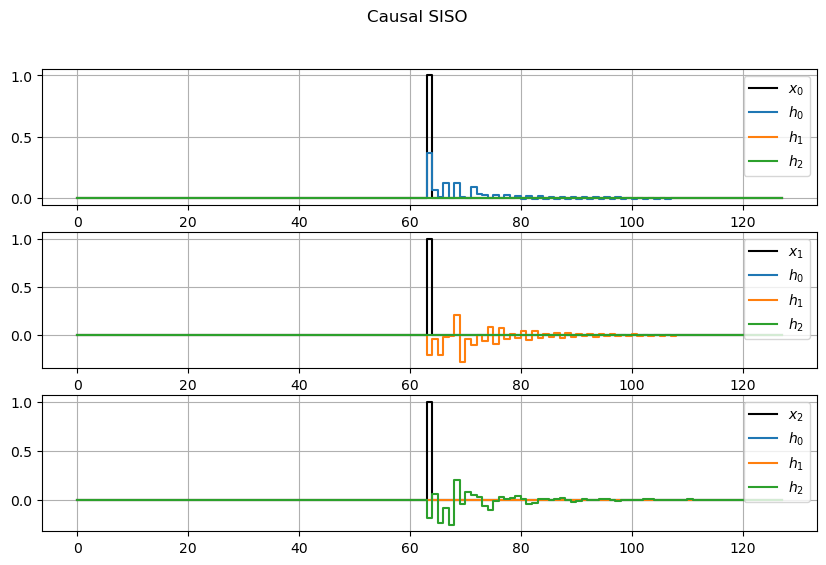

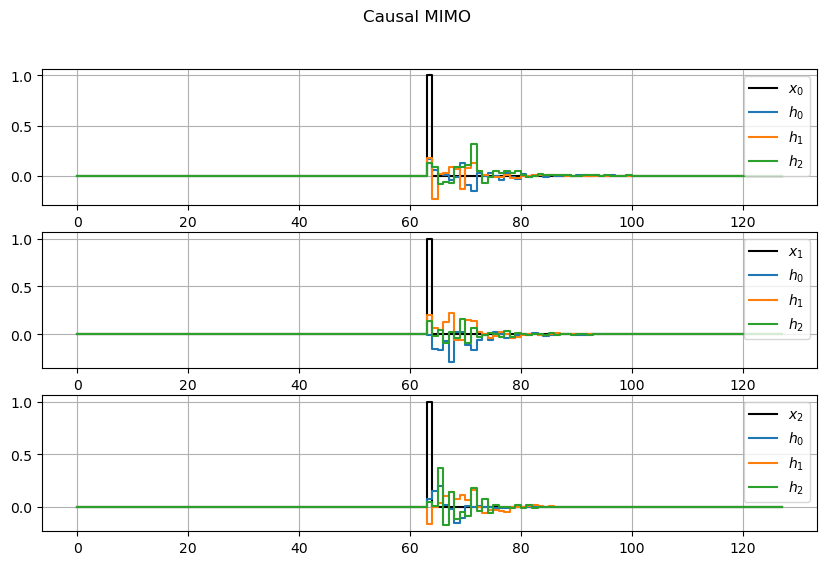

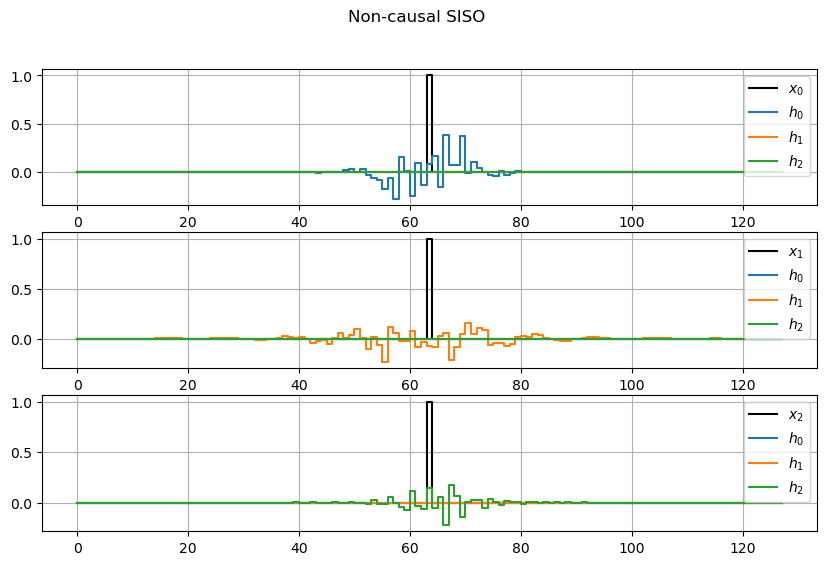

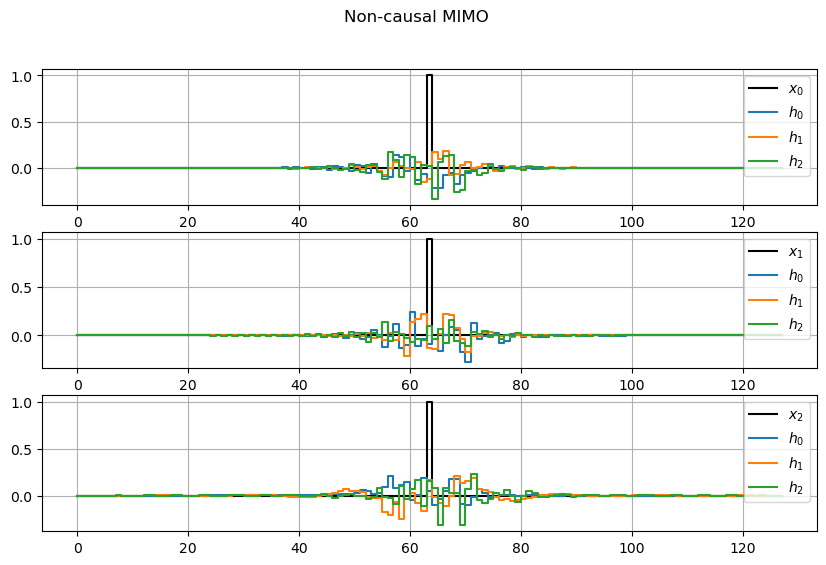

In [2]:
def plot_impulse_response(model, L=128, D=3, title=""):
    plt.figure(figsize=(10, 2 * D))
    for i in range(D):
        x = torch.zeros(L, D)
        x[L // 2, i] = 1
        h = model(x)

        plt.subplot(311 + i)
        plt.step(range(L), x[:, i].numpy(), "k", label=f"$x_{i}$")
        for j in range(D):
            plt.step(range(L), h[:, j].detach().numpy(), label=f"$h_{j}$")
        plt.legend()
        plt.grid()
    plt.suptitle(title)
    plt.show()


from models import LTI

L = 128
D = 3
model = LTI(input_dim=D, output_dim=D, order=8, causal=True, mimo=False, zero_init=False)
plot_impulse_response(model, L, D, title="Causal SISO")

model = LTI(input_dim=D, output_dim=D, order=8, causal=True, mimo=True, zero_init=False)
plot_impulse_response(model, L, D, title="Causal MIMO")

model = LTI(input_dim=D, output_dim=D, order=8, causal=False, mimo=False, zero_init=False)
plot_impulse_response(model, L, D, title="Non-causal SISO")

model = LTI(input_dim=D, output_dim=D, order=8, causal=False, mimo=True, zero_init=False)
plot_impulse_response(model, L, D, title="Non-causal MIMO")

# 2D

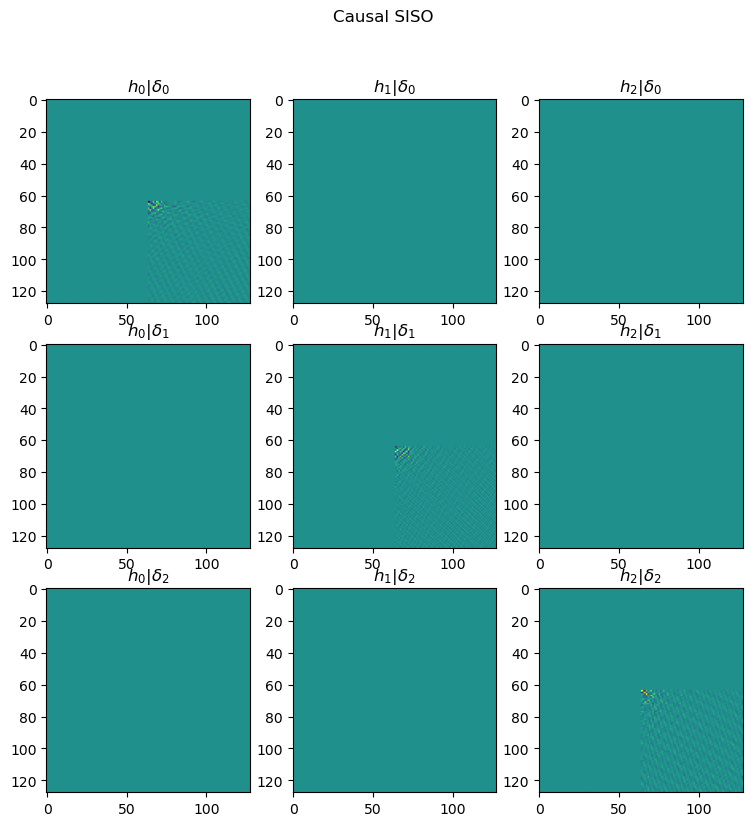

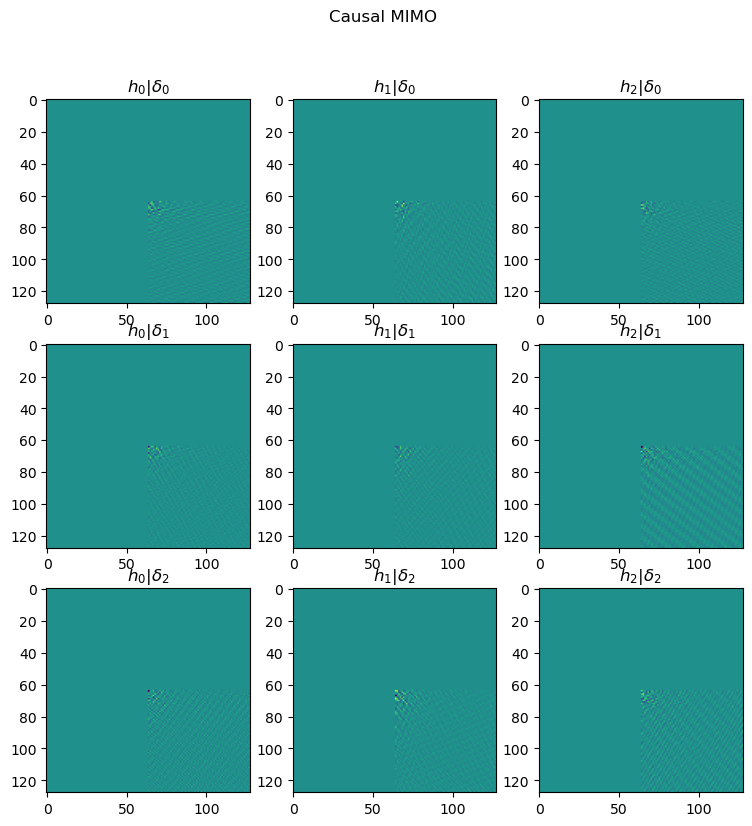

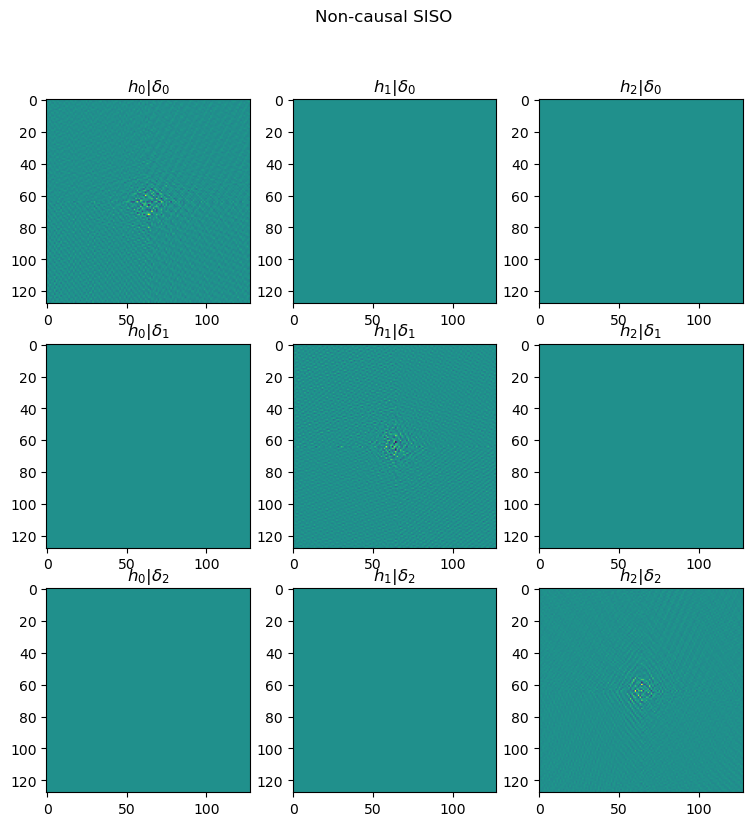

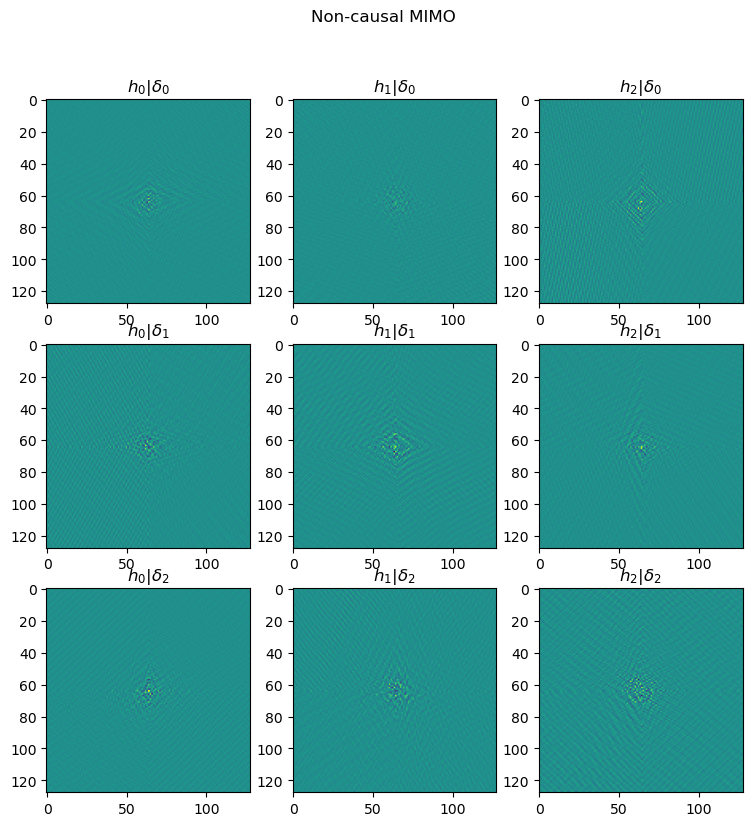

In [3]:
def plot_impulse_response(model, L1=128, L2=128, D=3, title=""):
    plt.figure(figsize=(3 * D, 3 * D))
    for i in range(D):
        x = torch.zeros(L1, L2, D)
        x[L1 // 2, L2 // 2, i] = 1
        h = model(x)
        for j in range(D):
            plt.subplot(D, D, 1 + D * i + j)
            plt.title(f"$h_{j} | \\delta_{i}$")
            r = min(h.max().abs(), h.min().abs())
            plt.imshow(h[:, :, j].detach().numpy(), vmin=-r, vmax=r)
    plt.suptitle(title)
    plt.show()


from models import LTI2d

L1 = L2 = 128
D = 3
model = LTI2d(input_dim=D, output_dim=D, order=8, causal=True, mimo=False, zero_init=False)
plot_impulse_response(model, L1, L2, D, title="Causal SISO")

model = LTI2d(input_dim=D, output_dim=D, order=8, causal=True, mimo=True, zero_init=False)
plot_impulse_response(model, L1, L2, D, title="Causal MIMO")

model = LTI2d(input_dim=D, output_dim=D, order=8, causal=False, mimo=False, zero_init=False)
plot_impulse_response(model, L1, L2, D, title="Non-causal SISO")

model = LTI2d(input_dim=D, output_dim=D, order=8, causal=False, mimo=True, zero_init=False)
plot_impulse_response(model, L1, L2, D, title="Non-causal MIMO")